# Analyze Results — PM-BG-AES demo measurements
Reads `results/raw/*.csv` produced by `python scripts/reproduce_all.py` and displays the latest run.

> These are new local demonstration measurements, not reproductions of the manuscript's original numerical results.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('src'))
import csv, glob, os
run = open('results/.run_id').read().strip()
print('latest run:', run)
rows = list(csv.DictReader(open('results/summary/performance_summary.csv')))
print(f"{len(rows)} (dataset, phase) groups")
for r in rows:
    print(f"{r['dataset_id']:10s} {r['phase']:7s} tp_mean={float(r['throughput_mean_mib_s']):8.2f} MiB/s  t_mean={float(r['elapsed_mean_s']):.4f}s  n={r['n_runs']}")

latest run: smoke01
22 (dataset, phase) groups
DEMO-001   decrypt tp_mean=    0.31 MiB/s  t_mean=0.0001s  n=5
DEMO-001   encrypt tp_mean=    0.00 MiB/s  t_mean=0.0001s  n=5
DEMO-002   decrypt tp_mean=    0.43 MiB/s  t_mean=0.0002s  n=5
DEMO-002   encrypt tp_mean=    0.10 MiB/s  t_mean=0.0003s  n=5
DEMO-003   decrypt tp_mean=   26.13 MiB/s  t_mean=0.0002s  n=5
DEMO-003   encrypt tp_mean=   16.38 MiB/s  t_mean=0.0004s  n=5
DEMO-004   decrypt tp_mean=   24.99 MiB/s  t_mean=0.0002s  n=5
DEMO-004   encrypt tp_mean=   12.41 MiB/s  t_mean=0.0005s  n=5
DEMO-005   decrypt tp_mean=   49.53 MiB/s  t_mean=0.0020s  n=5
DEMO-005   encrypt tp_mean=   32.96 MiB/s  t_mean=0.0031s  n=5
DEMO-006   decrypt tp_mean=   51.20 MiB/s  t_mean=0.0112s  n=5
DEMO-006   encrypt tp_mean=   47.78 MiB/s  t_mean=0.0120s  n=5
DEMO-007   decrypt tp_mean=    2.51 MiB/s  t_mean=0.0002s  n=5
DEMO-007   encrypt tp_mean=    0.88 MiB/s  t_mean=0.0005s  n=5
DEMO-008   decrypt tp_mean=   20.67 MiB/s  t_mean=0.2475s  n=5
DEMO-008

In [2]:
integ = list(csv.DictReader(open('results/summary/integrity_summary.csv')))
print('roundtrip:', all(r['roundtrip_status']=='ok' and r['exact_byte_match']=='1' for r in integ), f'({len(integ)} datasets)')
for r in integ:
    print(r['dataset_id'], r['roundtrip_status'], 'match='+r['exact_byte_match'])

roundtrip: True (11 datasets)
DEMO-001 ok match=1
DEMO-002 ok match=1
DEMO-003 ok match=1
DEMO-004 ok match=1
DEMO-005 ok match=1
DEMO-006 ok match=1
DEMO-007 ok match=1
DEMO-008 ok match=1
DEMO-009 ok match=1
DEMO-010 ok match=1
DEMO-011 ok match=1


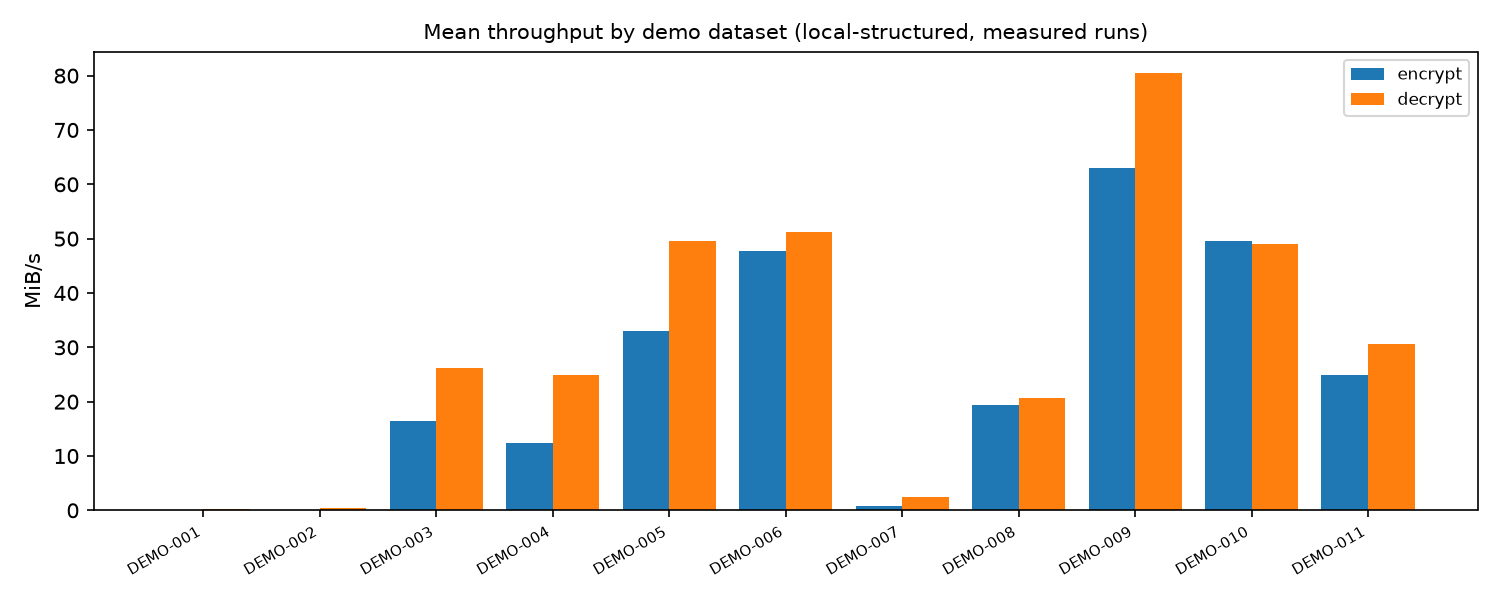

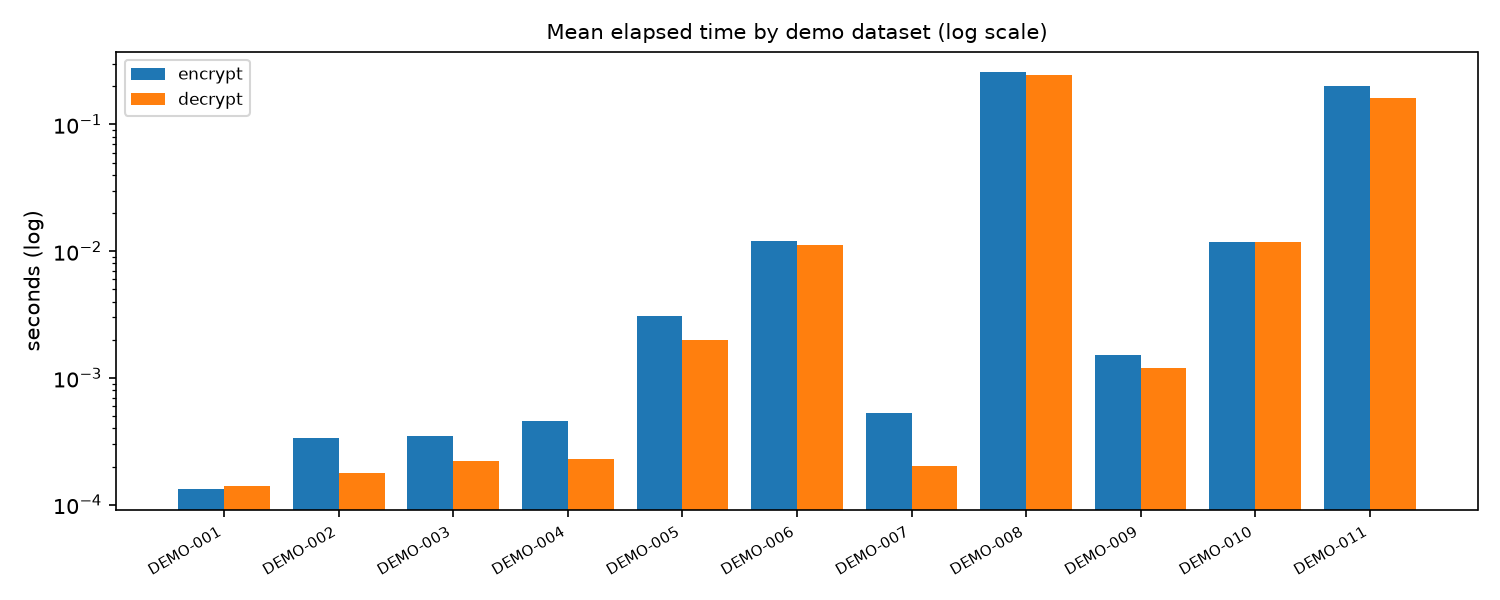

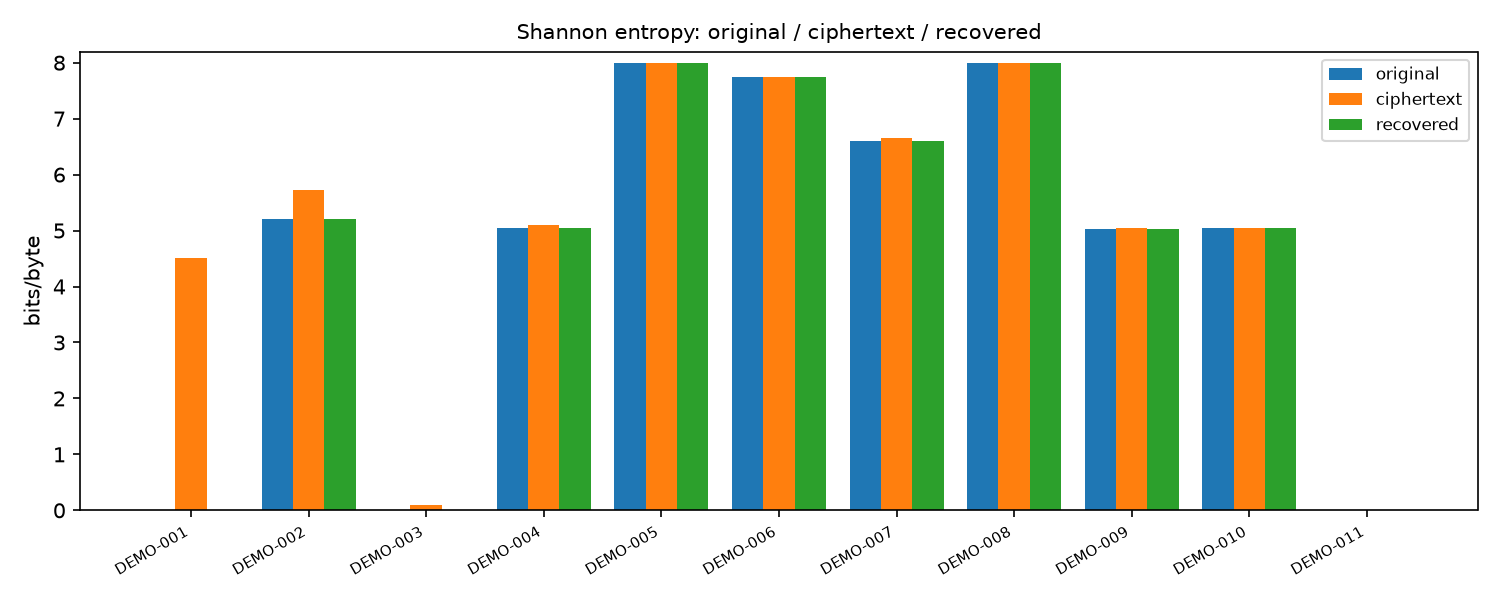

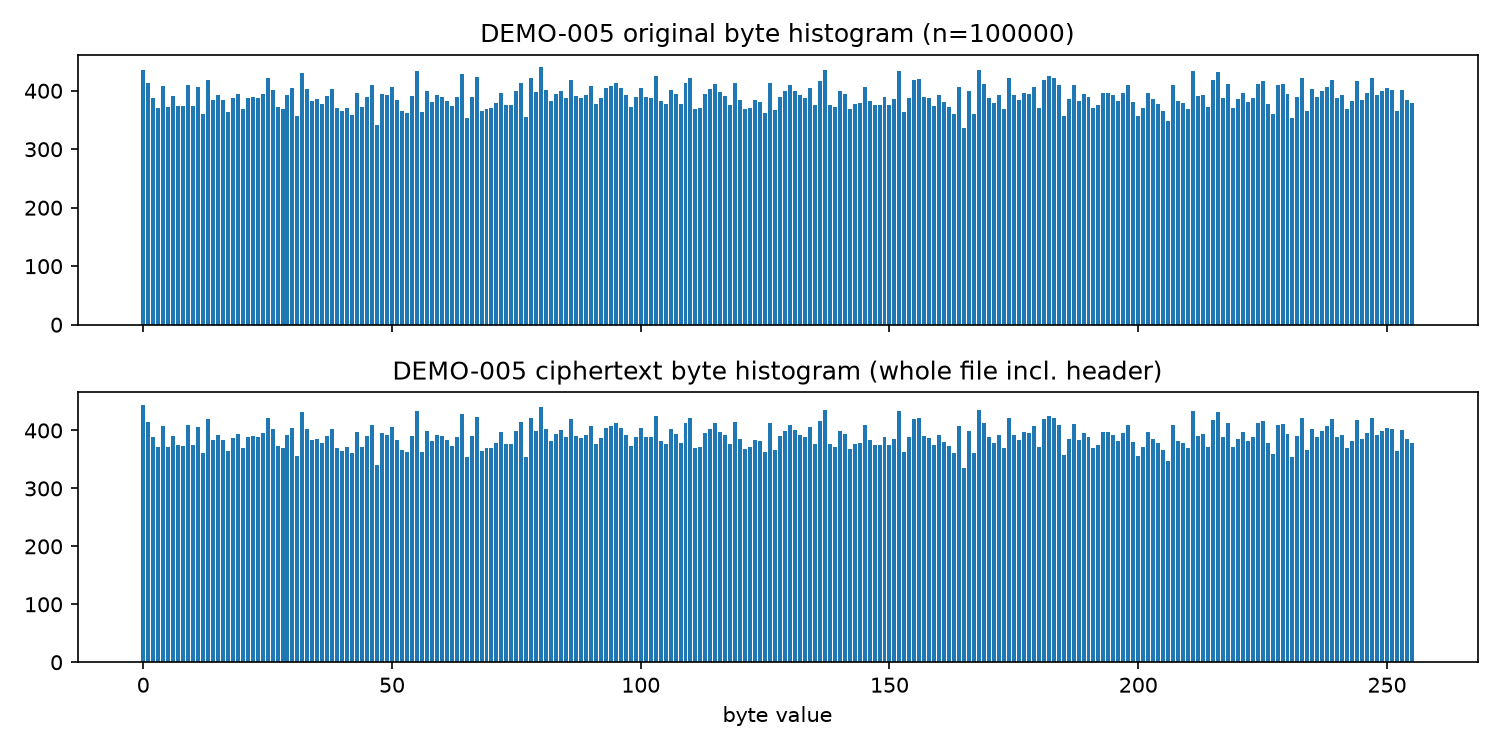

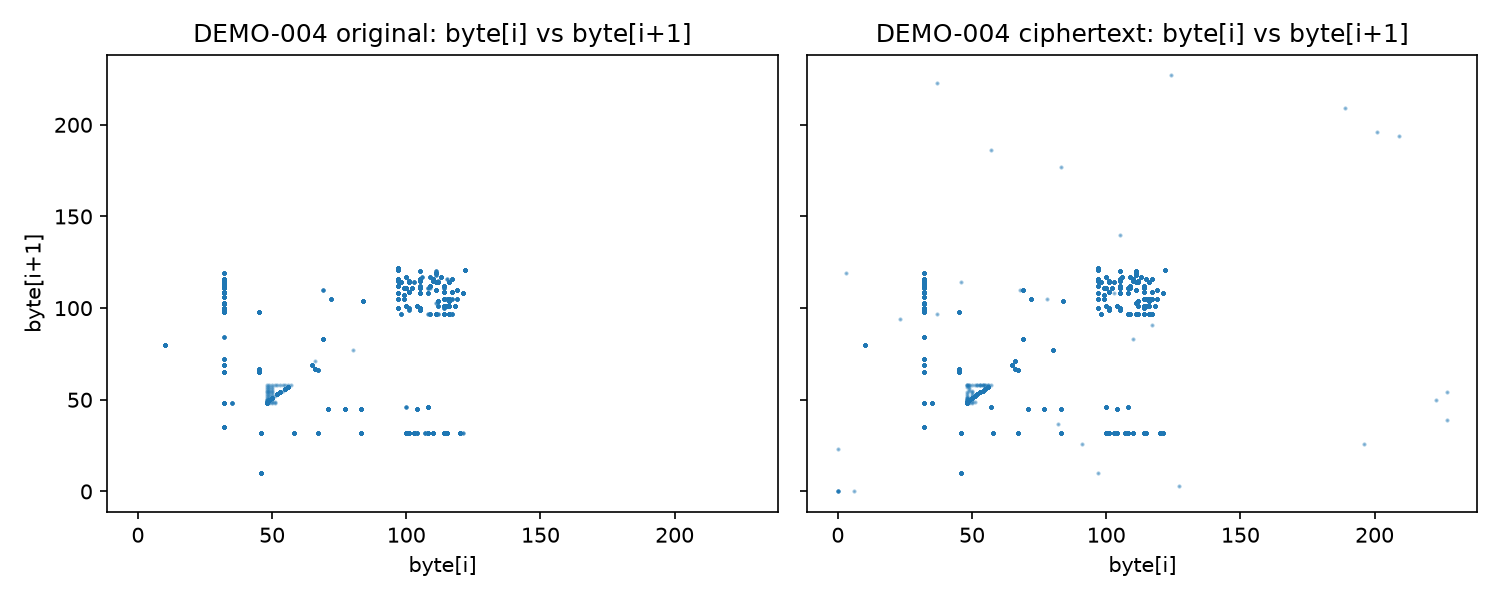

In [3]:
from IPython.display import Image, display
for f in ['demo_throughput.png', 'demo_elapsed.png', 'demo_entropy.png', 'demo_hist_DEMO-005.png', 'demo_scatter_DEMO-004.png']:
    display(Image(f'results/figures/{f}', width=800))